# <h1><center>CodeIT AI Engineer 3기 Mission 7</center></h1>


## 문제

이번 미션에서는 SSD 모델을 활용하여 개와 고양이의 얼굴(Face) 영역을 감지하는 Object Detection 작업을 수행해 봅시다.

## 데이터셋


데이터 링크: https://www.kaggle.com/datasets/devdgohil/the-oxfordiiit-pet-dataset
- annotations(xml): 각 이미지 파일에 대한 annotation
- images: 이미지 파일

In [1]:
import random

import os
import xml.etree.ElementTree as ET
import pandas as pd

import cv2
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm # 진행 상황 시각화

from torchvision.ops import box_iou
from torchvision.transforms import v2
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSD300_VGG16_Weights

from torchmetrics.detection.mean_ap import MeanAveragePrecision

from sklearn.model_selection import train_test_split

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cpu':
    # macOS에서 MPS 사용 가능 여부 확인
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

/Users/kimjaeyong/Documents/study/toy_projects/codeit/myvenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kimjaeyong/Documents/study/toy_projects/codeit/myvenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mps


## 데이터 로드

In [3]:
train_file_path = os.path.join('data', 'annotations', 'trainval.txt')
test_file_path = os.path.join("data", "annotations", "test.txt")

# Train 파일 읽기
df_trainval = pd.read_csv(train_file_path, sep='\s+', header=None)
df_trainval.columns = ['Image', 'ClassID', 'Species', 'BreedID']

df_trainval['Image'] = df_trainval['Image'].apply(lambda x: x + '.jpg')


# Test 파일 읽기
df_test = pd.read_csv(test_file_path, sep="\s+", header=None)
df_test.columns = ["Image", "ClassID", "Species", "BreedID"]

df_test['Image'] = df_test['Image'].apply(lambda x: x + '.jpg')

In [ ]:
# XML 파일에서 어노테이션을 파싱하여 DataFrame으로 변환
def parse_annotations(annotation_dir):
    data = []
    for file in os.listdir(annotation_dir):
        if not file.endswith('.xml'):
            continue
        tree = ET.parse(os.path.join(annotation_dir, file))
        root = tree.getroot()

        filename = root.find('filename').text
        for obj in root.findall('object'):
            label = obj.find('name').text
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            data.append([filename, label, xmin, ymin, xmax, ymax])
    
    df = pd.DataFrame(data, columns=['filename', 'label', 'xmin', 'ymin', 'xmax', 'ymax'])
    return df


In [4]:
df = parse_annotations('./data/annotations/xmls')
train_files, val_files = train_test_split(df_trainval['Image'].unique(), test_size=0.2, random_state=42)

df_train = df[df['filename'].isin(train_files)].reset_index(drop=True)
df_val = df[df['filename'].isin(val_files)].reset_index(drop=True)

print(f'Train samples: {len(df_train)}, Validation samples: {len(df_val)}')

Train samples: 2937, Validation samples: 735


## 이미지 시각화

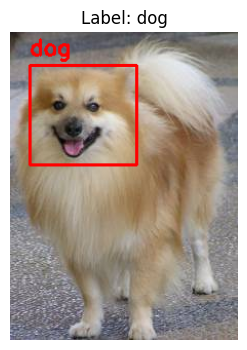

In [5]:
def visualize_sample(image_dir, df, index):
    row = df.iloc[index]
    img_path = os.path.join(image_dir, row['filename'])

    # 이미지 불러오기
    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지를 찾을 수 없습니다: {img_path}")
        return

    # BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 바운딩 박스 그리기
    xmin, ymin, xmax, ymax = row[['xmin', 'ymin', 'xmax', 'ymax']]
    label = row['label']
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
    cv2.putText(img, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    # 출력
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

# 이미지 폴더 경로
image_dir = './data/images'
visualize_sample(image_dir, df, 4)

## 학습 데이터 준비

In [6]:
# 클래스 이름을 숫자로 매핑
label_map = {'cat': 1, 'dog': 2}  # 0은 배경 클래스(background)

class PetDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform
        self.image_names = df['filename'].unique()

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        filename = self.image_names[idx]
        image_path = os.path.join(self.image_dir, filename)

        # 이미지 로드
        image = Image.open(image_path).convert("RGB")

        # 해당 이미지에 대한 모든 바운딩 박스 추출
        records = self.df[self.df['filename'] == filename]
        boxes = records[['xmin', 'ymin', 'xmax', 'ymax']].values
        labels = [label_map[label] for label in records['label']]

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {'boxes': boxes, 'labels': labels}

        if self.transform:
            image = self.transform(image)

        return image, target


In [7]:
transform = v2.Compose([
    v2.Resize((300, 300)),  # SSD300은 300x300 입력
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.ToTensor()
])

train_dataset = PetDataset(df_train, image_dir, transform=transform)
val_dataset = PetDataset(df_val, image_dir, transform=transform)

# 데이터 확인
img, target = train_dataset[0]
print(f"Image shape: {img.shape}")
print(f"Target: {target}")

Image shape: torch.Size([3, 300, 300])
Target: {'boxes': tensor([[ 83.,  29., 197., 142.]]), 'labels': tensor([1])}


/Users/kimjaeyong/Documents/study/toy_projects/codeit/myvenv/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


## SSD 모델 불러오기

In [ ]:
# 클래스 수: 배경(0) + 고양이(1) + 개(2) = 3
num_classes = 3

# 사전학습된 SSD 모델 불러오기
model = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT).to(device)
model.head.classification_head.num_classes = num_classes

In [9]:
# Optimizer 정의
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.002, momentum=0.9, weight_decay=5e-4)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

## 학습 및 검증 루프

In [15]:
def compute_mean_iou(preds, gts, score_thresh=0.3):
    iou_list = []

    for pred, gt in zip(preds, gts):
        keep = pred['scores'] > score_thresh
        pred_boxes = pred['boxes'][keep]
        gt_boxes = gt['boxes']

        if len(pred_boxes) == 0 or len(gt_boxes) == 0:
            continue

        ious = box_iou(pred_boxes, gt_boxes)
        max_ious = ious.max(dim=1).values
        iou_list.extend(max_ious.tolist())

    if len(iou_list) == 0:
        return 0.0
    return sum(iou_list) / len(iou_list)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for images, targets in tqdm(train_loader, desc="Training"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_train_loss += losses.item()

    avg_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch + 1} - Avg Train Loss: {avg_loss:.4f}")

    model.eval()
    metric = MeanAveragePrecision(iou_type='bbox', class_metrics=True)
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="Validating"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images)

            # CPU 이동 및 score threshold 적용
            preds_cpu = []
            for out in outputs:
                keep = out['scores'] > 0.5
                preds_cpu.append({
                    'boxes': out['boxes'][keep].cpu(),
                    'scores': out['scores'][keep].cpu(),
                    'labels': out['labels'][keep].cpu()
                })
            targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]

            all_preds.extend(preds_cpu)
            all_targets.extend(targets_cpu)

            metric.update(preds_cpu, targets_cpu)

    # 평가 결과 출력
    result = metric.compute()
    mean_iou = compute_mean_iou(all_preds, all_targets, score_thresh=0.5)

    print(f"Epoch {epoch + 1} - mAP: {result['map']:.4f}, Avg IoU: {mean_iou:.4f}")
    

Training: 100%|██████████| 367/367 [02:56<00:00,  2.08it/s]


Epoch 1 - Avg Train Loss: 1.7762


Epoch 1 - mAP: 0.2095, Avg IoU: 0.5720


Training: 100%|██████████| 367/367 [02:54<00:00,  2.10it/s]


Epoch 2 - Avg Train Loss: 1.6401


...

Epoch 9 - Avg Train Loss: 1.0308


Epoch 9 - mAP: 0.2253, Avg IoU: 0.6104


Training: 100%|██████████| 367/367 [02:53<00:00,  2.11it/s]


Epoch 10 - Avg Train Loss: 0.9889


Epoch 10 - mAP: 0.2377, Avg IoU: 0.6213


## 시각화

In [25]:
def predict_and_plot(image_path, model, threshold=0.5):
    model.eval()
    
    # 이미지 로드 및 전처리
    image = Image.open(image_path).convert("RGB")
    transform = v2.Compose([v2.Resize((300, 300)), v2.ToTensor()])
    image_tensor = transform(image).unsqueeze(0).to(device)

    # 예측
    with torch.no_grad():
        outputs = model(image_tensor)[0]

    # 원본 이미지 다시 로드 (시각화용)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    for box, label, score in zip(outputs['boxes'], outputs['labels'], outputs['scores']):
        if score < threshold:
            continue

        box = box.to('cpu').numpy().astype(int)
        x1, y1, x2, y2 = box
        label_name = 'cat' if label.item() == 1 else 'dog' if label.item() == 2 else 'unknown'
        text = f"{label_name} {score:.2f}"

        # 박스 그리기
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # 텍스트 여백 조절
        text_y = y1 - 10 if y1 - 10 > 10 else y1 + 20  # 위에 여백이 부족하면 아래로
        cv2.putText(image, text, (x1, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # 출력
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Prediction")
    plt.tight_layout(pad=2)  # 전체 플롯에도 여백 추가
    plt.show()

/Users/kimjaeyong/Documents/study/toy_projects/codeit/myvenv/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


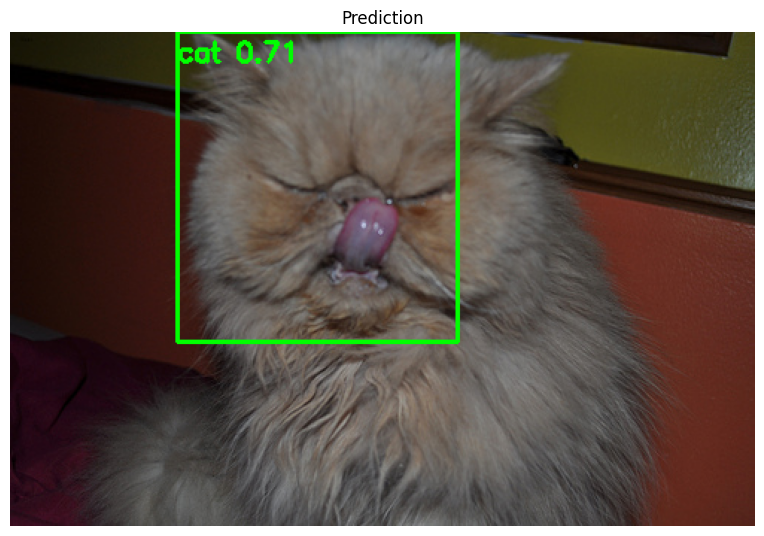

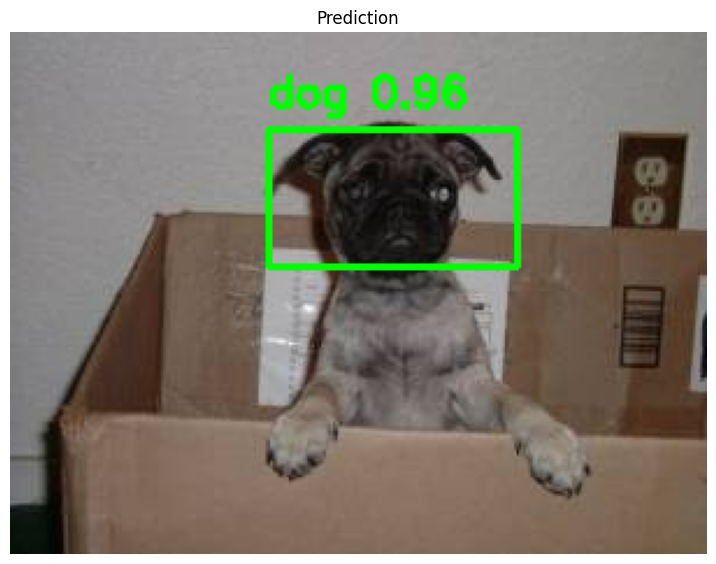

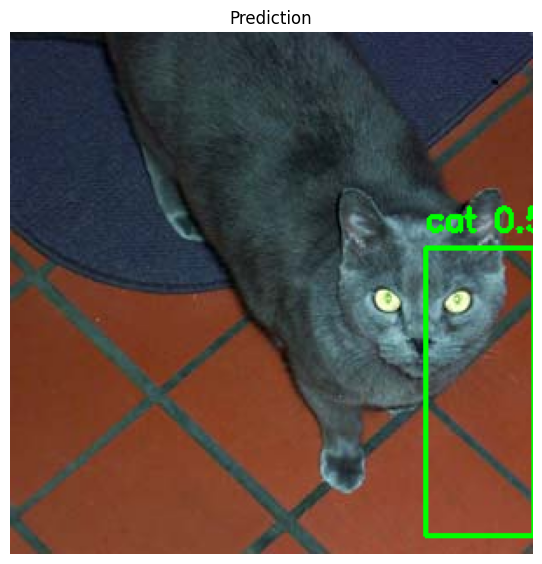

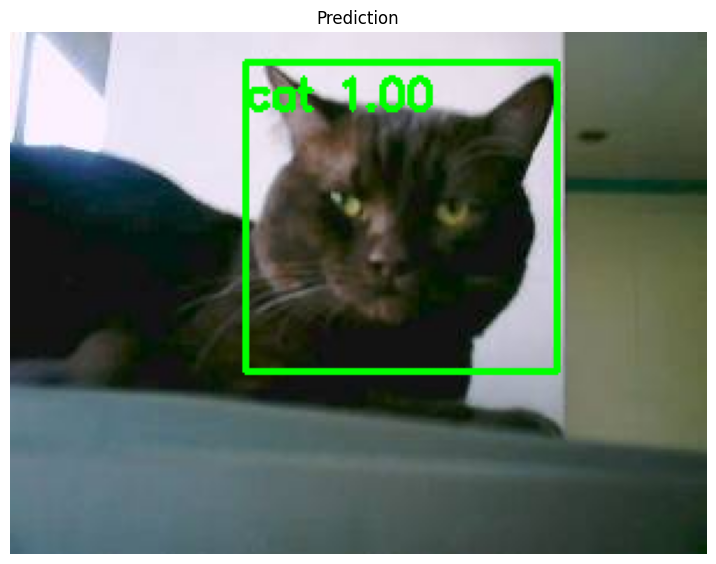

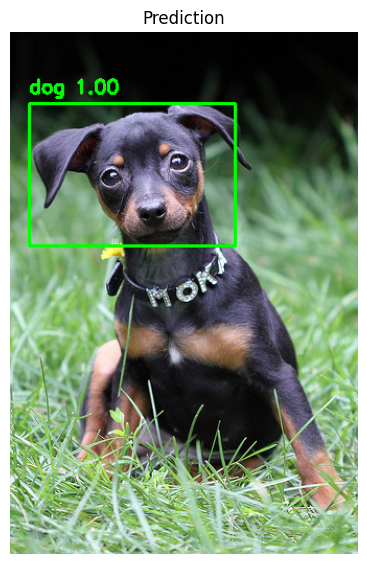

In [28]:
for i in range(5):
	# 테스트 이미지 경로 (이전에 쓰던 이미지 중 하나 선택)
	test_img_path = os.path.join(image_dir, df_test['Image'].iloc[random.randint(1, len(df_test)-1)])
	predict_and_plot(test_img_path, model, threshold=0.5)